# 6. Explicabilité des Modèles

**Projet Semesteriel - Détection de Fake News COVID-19**  
**Niveau 4CS | Superviseur : Prof. Salem Trabelsi**

---

## Objectif

Ce notebook explore l'explicabilité des modèles de détection de fake news :
- **Visualisation de l'attention** (BERT)
- **LIME** (Local Interpretable Model-agnostic Explanations)
- **SHAP** (SHapley Additive exPlanations)
- Comparaison des méthodes
- Analyse des biais
- Considérations éthiques

L'explicabilité est cruciale pour la confiance et l'adoption du modèle, particulièrement dans un domaine sensible comme la détection de désinformation.

## 6.1 Importation des bibliothèques

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from transformers import (
    BertTokenizer, BertForSequenceClassification, BertModel,
    DistilBertTokenizer, DistilBertForSequenceClassification, DistilBertModel
)

import warnings
warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible.")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installe.")

try:
    import lime
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
    print("LIME disponible.")
except ImportError:
    LIME_AVAILABLE = False
    print("LIME non installe.")

sys.path.insert(0, os.path.join('..', 'src'))
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
print("\nBibliotheques importees avec succes.")

SHAP disponible.
LIME disponible.

Bibliotheques importees avec succes.


## 6.2 Chargement du modèle et des données

In [2]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Charger les métadonnées
with open(os.path.join(PROCESSED_DIR, 'metadata.json'), 'r') as f:
    metadata = json.load(f)

label_names = list(metadata['label_mapping'].keys())
print(f"Classes : {label_names}")

# Charger les données de test
df_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_processed.csv'))
print(f"Données de test : {len(df_test)} exemples")

Device : cpu
Classes : ['fake', 'real']
Données de test : 2140 exemples


In [3]:
# Charger le meilleur modele disponible (DistilBERT ou BERT)
bert_dir = os.path.join(MODELS_DIR, 'bert_best')
db_dir = os.path.join(MODELS_DIR, 'distilbert_best')

model = None
tokenizer = None
model_type = None

if os.path.exists(db_dir):
    tokenizer = DistilBertTokenizer.from_pretrained(db_dir)
    model = DistilBertForSequenceClassification.from_pretrained(
        db_dir, output_attentions=True, attn_implementation='eager'
    )
    model_type = 'distilbert'
    print(f"DistilBERT charge depuis {db_dir}")
elif os.path.exists(bert_dir):
    tokenizer = BertTokenizer.from_pretrained(bert_dir)
    model = BertForSequenceClassification.from_pretrained(
        bert_dir, output_attentions=True
    )
    model_type = 'bert'
    print(f"BERT charge depuis {bert_dir}")
else:
    # Charger un modele par defaut
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=len(label_names),
        output_attentions=True, attn_implementation='eager'
    )
    model_type = 'distilbert'
    print("Modele par defaut charge (non fine-tune).")

model = model.to(device)
model.eval()
print(f"Type de modele : {model_type}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT charge depuis ..\models\distilbert_best
Type de modele : distilbert


In [4]:
# Fonctions utilitaires
def predict_single(text, return_attention=False):
    """Predire la classe d'un texte unique avec optionnellement les poids d'attention."""
    encoding = tokenizer(
        text,
        max_length=128,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    logits = outputs.logits
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred = np.argmax(probs)
    
    result = {
        'prediction': label_names[pred],
        'probabilities': {label_names[i]: float(probs[i]) for i in range(len(label_names))},
        'confidence': float(probs.max())
    }
    
    if return_attention and outputs.attentions is not None:
        attentions = [a.cpu().numpy() for a in outputs.attentions]
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
        result['attentions'] = attentions
        result['tokens'] = tokens
        result['attention_mask'] = attention_mask.cpu().numpy()[0]
    
    return result

def predict_batch(texts):
    """Predire pour un batch de textes (utilise par LIME)."""
    all_probs = []
    for text in texts:
        result = predict_single(text)
        probs = [result['probabilities'][name] for name in label_names]
        all_probs.append(probs)
    return np.array(all_probs)

In [5]:
print("Fonctions utilitaires definies.")

Fonctions utilitaires definies.


## 6.3 Visualisation de l'attention

Les mécanismes d'attention de BERT nous permettent de voir quels tokens le modèle considère comme importants pour sa décision.

In [6]:
def visualize_attention(text, layer=-1, head=None, figsize=(16, 4)):
    """
    Visualiser les poids d'attention pour un texte donné.
    
    Args:
        text: Le texte à analyser
        layer: La couche d'attention à visualiser (-1 pour la dernière)
        head: La tête d'attention spécifique (None pour la moyenne)
    """
    result = predict_single(text, return_attention=True)
    
    if 'attentions' not in result:
        print("Les poids d'attention ne sont pas disponibles.")
        return
    
    attentions = result['attentions']
    tokens = result['tokens']
    mask = result['attention_mask']
    
    # Nombre de vrais tokens (sans padding)
    n_tokens = int(mask.sum())
    tokens = tokens[:n_tokens]
    
    # Obtenir l'attention de la couche spécifiée
    # shape: (batch, n_heads, seq_len, seq_len)
    attn = attentions[layer][0]  # Premier (seul) élément du batch
    
    if head is not None:
        attn_weights = attn[head, :n_tokens, :n_tokens]
        title_suffix = f'(Couche {layer}, Tête {head})'
    else:
        # Moyenne sur toutes les têtes
        attn_weights = attn[:, :n_tokens, :n_tokens].mean(axis=0)
        title_suffix = f'(Couche {layer}, Moyenne des têtes)'
    
    # Attention reçue par chaque token depuis [CLS]
    cls_attention = attn_weights[0]  # Attention du token [CLS] vers tous les autres
    
    # Visualisation heatmap
    fig, axes = plt.subplots(1, 2, figsize=(figsize[0], max(figsize[1], n_tokens * 0.25)))
    
    # Heatmap complète
    display_tokens = [t[:15] for t in tokens]  # Tronquer les tokens longs
    if n_tokens <= 40:  # Limiter pour la lisibilité
        sns.heatmap(
            attn_weights, xticklabels=display_tokens, yticklabels=display_tokens,
            cmap='YlOrRd', ax=axes[0], square=True
        )
        axes[0].set_title(f'Matrice d\'attention {title_suffix}', fontweight='bold', fontsize=10)
        axes[0].tick_params(axis='both', labelsize=7)
    else:
        # Si trop de tokens, montrer seulement les 40 premiers
        sns.heatmap(
            attn_weights[:40, :40],
            xticklabels=display_tokens[:40], yticklabels=display_tokens[:40],
            cmap='YlOrRd', ax=axes[0], square=True
        )
        axes[0].set_title(f'Matrice d\'attention (40 premiers tokens) {title_suffix}', fontweight='bold', fontsize=10)
        axes[0].tick_params(axis='both', labelsize=6)
    
    # Barplot de l'attention depuis [CLS]
    top_k = min(25, len(cls_attention))
    top_indices = np.argsort(cls_attention)[-top_k:][::-1]
    top_tokens = [tokens[i] for i in top_indices]
    top_scores = cls_attention[top_indices]
    
    colors_bar = plt.cm.YlOrRd(top_scores / top_scores.max())
    axes[1].barh(range(len(top_tokens)), top_scores, color=colors_bar)
    axes[1].set_yticks(range(len(top_tokens)))
    axes[1].set_yticklabels(top_tokens)
    axes[1].invert_yaxis()
    axes[1].set_title(f'Top tokens (attention depuis [CLS])', fontweight='bold', fontsize=10)
    axes[1].set_xlabel('Poids d\'attention')
    
    # Ajouter la prédiction
    pred_text = f"Prédiction: {result['prediction']} ({result['confidence']:.1%})"
    fig.suptitle(pred_text, fontsize=12, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return result

In [7]:
print("Fonction visualize_attention définie.")

Fonction visualize_attention définie.


In [8]:
# Sélectionner des exemples représentatifs
text_col = metadata.get('text_column', 'cleaned_text')
display_col = text_col if text_col in df_test.columns else 'cleaned_text'
label_col_name = metadata.get('label_column', 'label_encoded')

# Exemples de fake news
fake_mask = df_test['label_encoded'] == 0
real_mask = df_test['label_encoded'] == 1

# Ajuster les masques si l'encodage est différent
if label_col_name in df_test.columns and df_test[label_col_name].dtype == object:
    fake_label = [k for k, v in metadata['label_mapping'].items() if 'fake' in k.lower()]
    real_label = [k for k, v in metadata['label_mapping'].items() if 'real' in k.lower()]

# Prendre des exemples de longueur raisonnable
df_test['_text_len'] = df_test['cleaned_text'].astype(str).apply(len)
medium_texts = df_test[(df_test['_text_len'] > 50) & (df_test['_text_len'] < 300)]

# Échantillons
fake_samples = medium_texts[medium_texts['label_encoded'] == 0].sample(min(2, sum(medium_texts['label_encoded'] == 0)), random_state=42)
real_samples = medium_texts[medium_texts['label_encoded'] == 1].sample(min(2, sum(medium_texts['label_encoded'] == 1)), random_state=42)

print(f"Exemples sélectionnés : {len(fake_samples)} fake, {len(real_samples)} real")

Exemples sélectionnés : 2 fake, 2 real


ATTENTION - EXEMPLES DE FAKE NEWS

--- Exemple Fake 1 ---
Texte : twitter suspended the account of aytu bioscience to make trump look bad


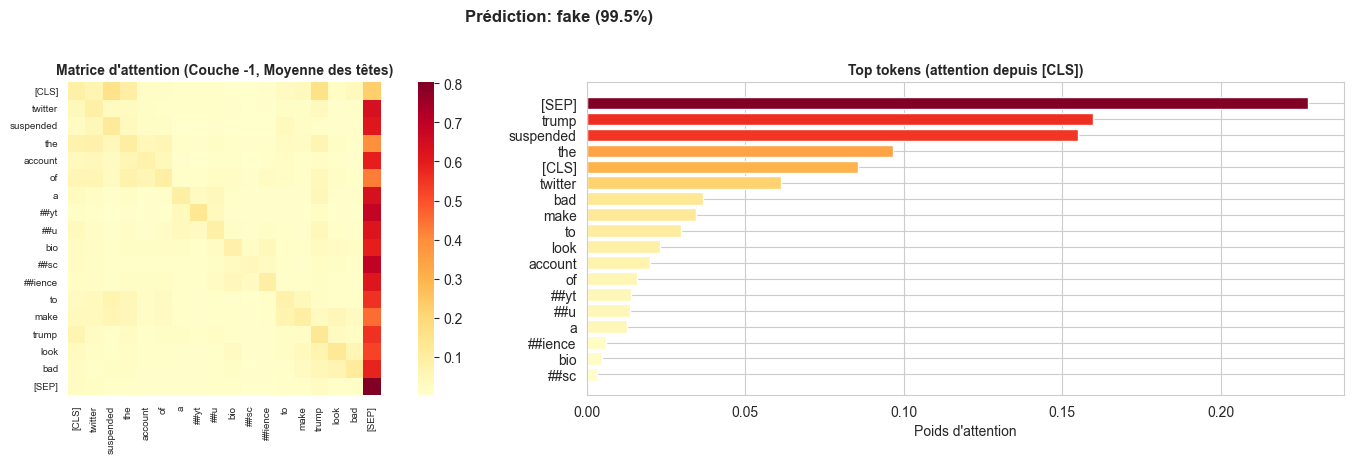


--- Exemple Fake 2 ---
Texte : avifavir the world s first favipiravir based drug to be approved for the treatment of covid 19 will now be delivered to saudi arabia brazil bulgaria serbia argentina chile colombia ecuador el salvador


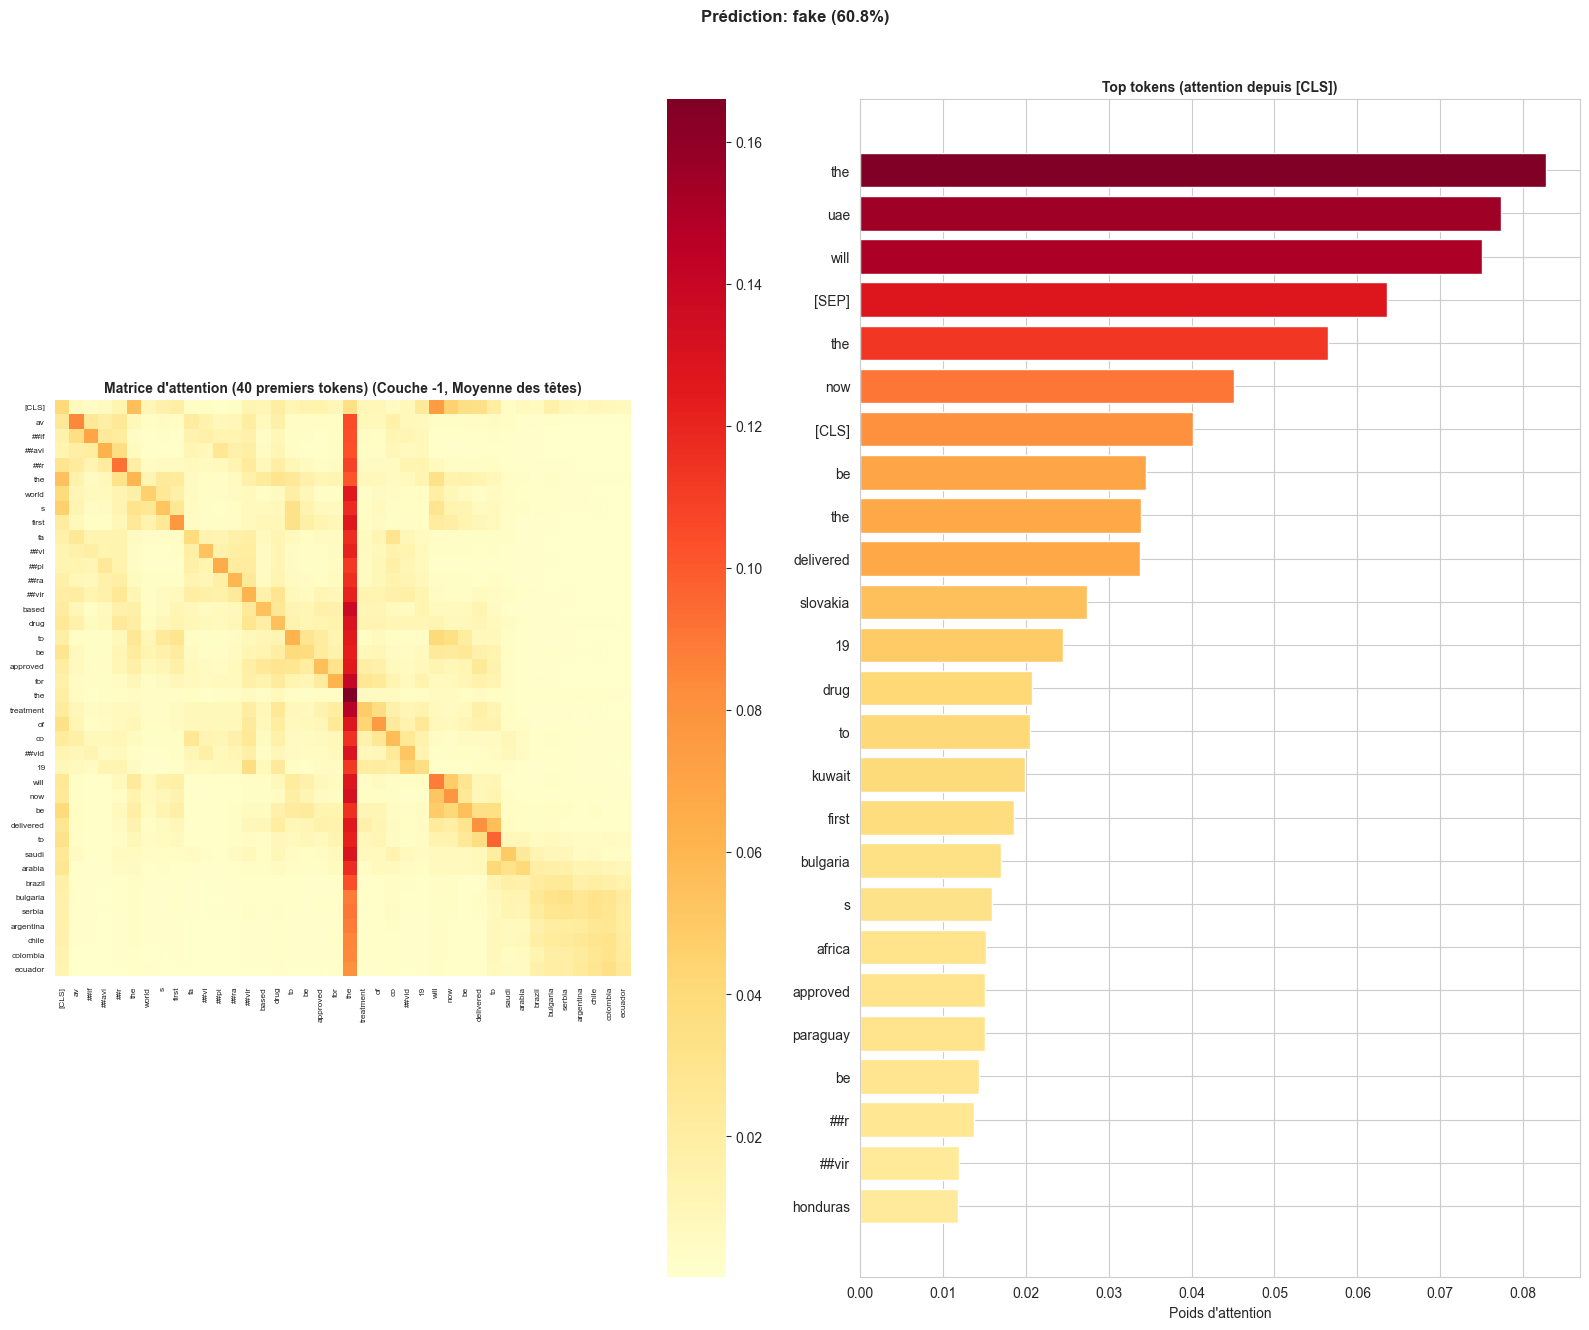

In [9]:
# Visualiser l'attention pour des exemples de fake news
print("=" * 60)
print("ATTENTION - EXEMPLES DE FAKE NEWS")
print("=" * 60)

for i, (_, row) in enumerate(fake_samples.iterrows()):
    text = str(row['cleaned_text'])
    print(f"\n--- Exemple Fake {i+1} ---")
    print(f"Texte : {text[:200]}")
    result = visualize_attention(text, layer=-1)
    plt.savefig(f'../reports/figures/attention_fake_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

ATTENTION - EXEMPLES DE REAL NEWS

--- Exemple Real 1 ---
Texte : rt niosh as a bank employer your workers could be exposed to the virus that causes covid19 while doing their job new information from


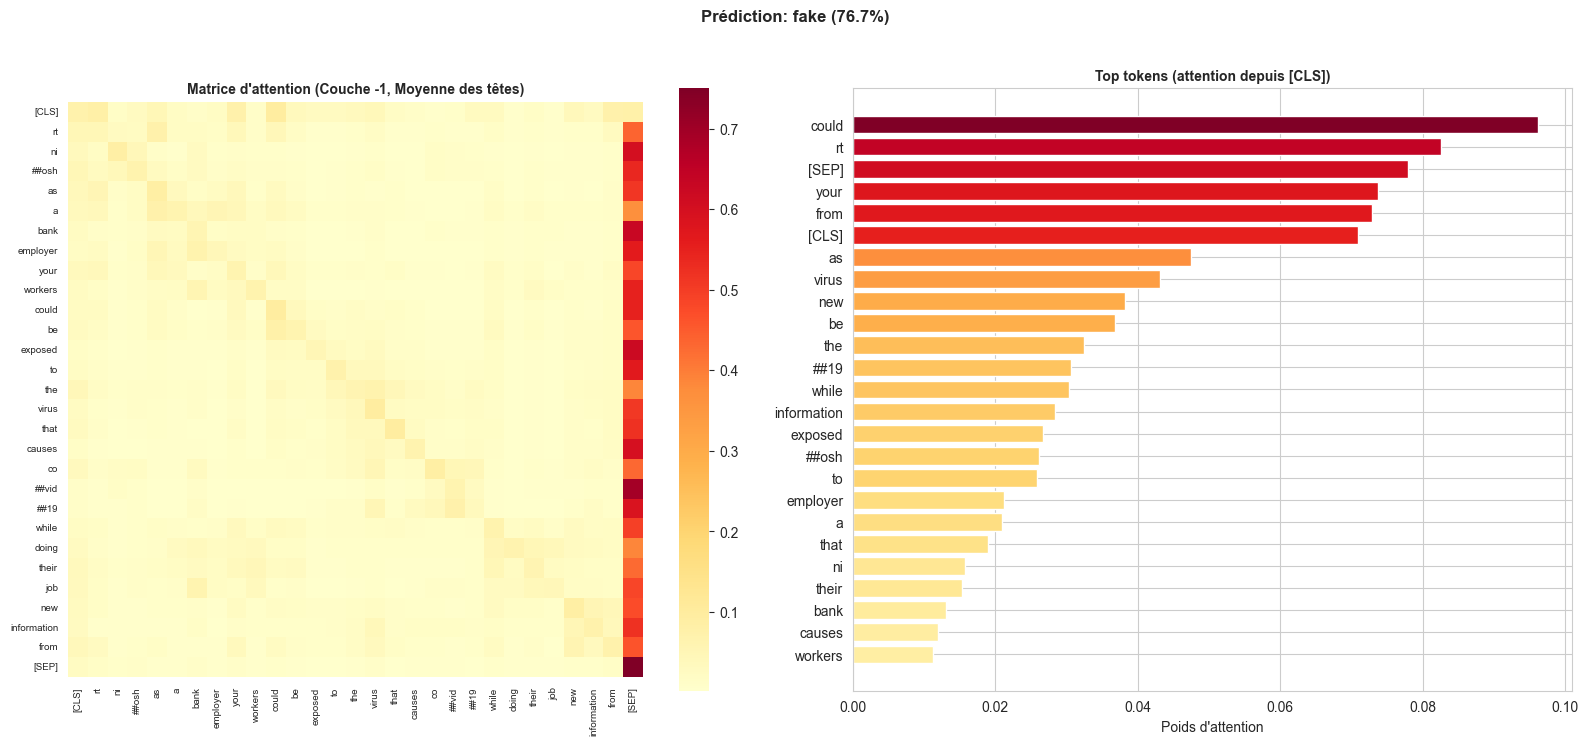


--- Exemple Real 2 ---
Texte : coronavirus slovenia and guadeloupe added to uk s quarantine list but thailand and singapore removed


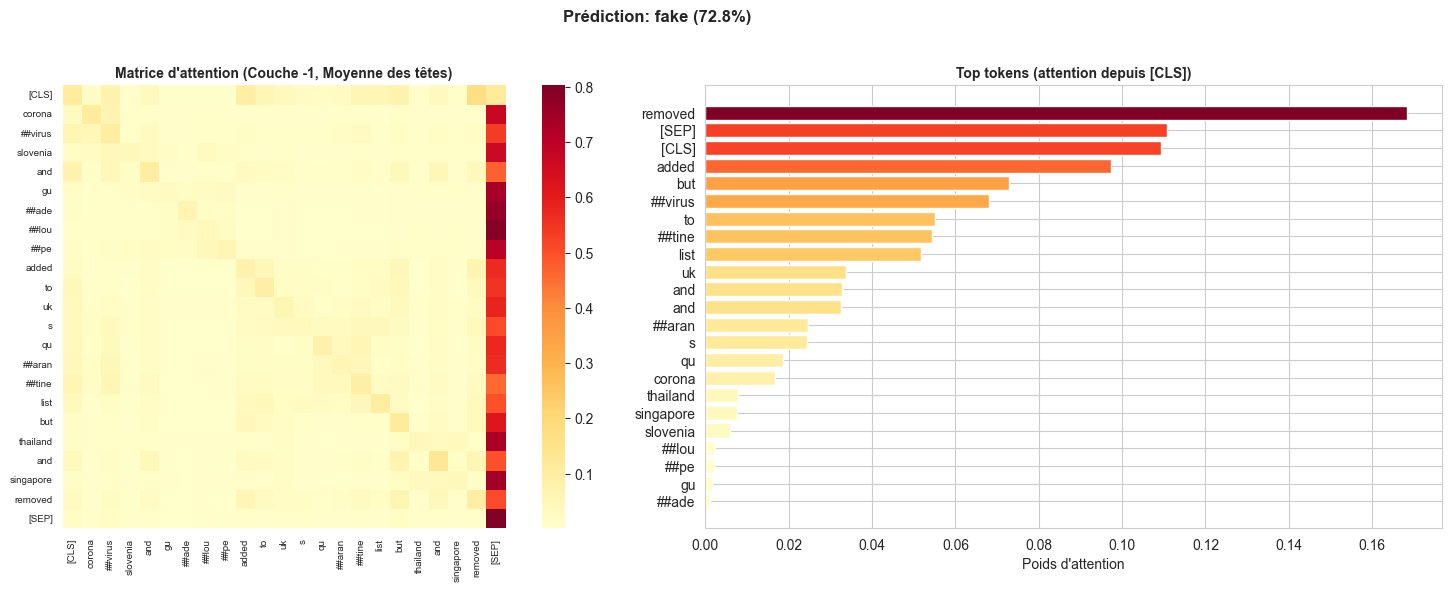

In [10]:
# Visualiser l'attention pour des exemples de real news
print("=" * 60)
print("ATTENTION - EXEMPLES DE REAL NEWS")
print("=" * 60)

for i, (_, row) in enumerate(real_samples.iterrows()):
    text = str(row['cleaned_text'])
    print(f"\n--- Exemple Real {i+1} ---")
    print(f"Texte : {text[:200]}")
    result = visualize_attention(text, layer=-1)
    plt.savefig(f'../reports/figures/attention_real_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6.4 Explications LIME

LIME (Local Interpretable Model-agnostic Explanations) crée des modèles linéaires locaux pour expliquer chaque prédiction individuelle.

In [11]:
if LIME_AVAILABLE:
    # Créer l'explainer LIME
    lime_explainer = LimeTextExplainer(
        class_names=label_names,
        split_expression=r'\s+',
        random_state=42
    )
    
    print("LIME Text Explainer créé.")
    print(f"Classes : {label_names}")
else:
    print("LIME non disponible. Installer avec : pip install lime")

LIME Text Explainer créé.
Classes : ['fake', 'real']


LIME - EXPLICATIONS POUR FAKE NEWS

--- Exemple Fake 1 ---
Texte : twitter suspended the account of aytu bioscience to make trump look bad
Vrai label : fake


Prédiction : fake (99.5%)

Mots les plus importants :
  twitter              : -0.0210 -> FAKE
  trump                : -0.0209 -> FAKE
  account              : -0.0151 -> FAKE
  bad                  : -0.0118 -> FAKE
  to                   : -0.0086 -> FAKE
  suspended            : -0.0080 -> FAKE
  look                 : -0.0055 -> FAKE
  make                 : -0.0042 -> FAKE
  aytu                 : -0.0026 -> FAKE
  bioscience           : -0.0022 -> FAKE
  the                  : +0.0019 -> REAL
  of                   : +0.0013 -> REAL


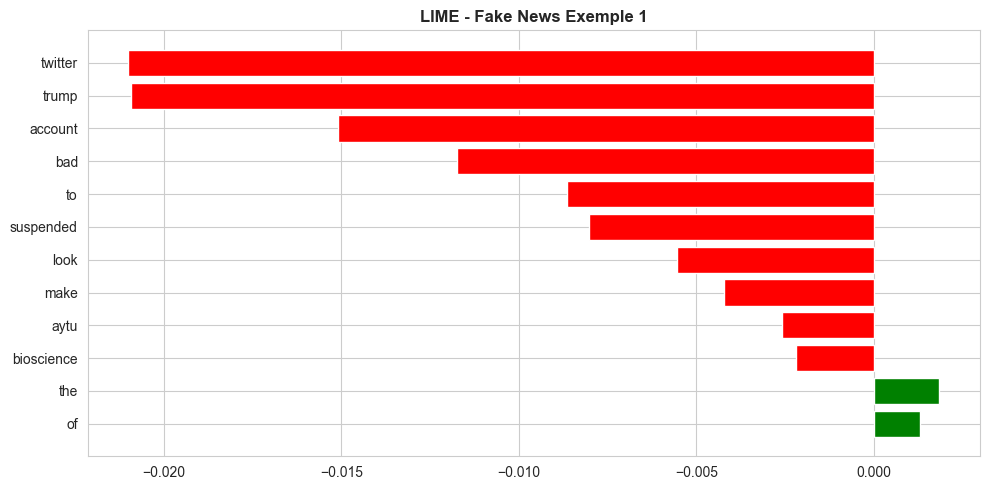


--- Exemple Fake 2 ---
Texte : avifavir the world s first favipiravir based drug to be approved for the treatment of covid 19 will now be delivered to saudi arabia brazil bulgaria serbia argentina chile colombia ecuador el salvador
Vrai label : fake


Prédiction : fake (60.8%)

Mots les plus importants :
  drug                 : -0.1098 -> FAKE
  be                   : +0.0922 -> REAL
  avifavir             : -0.0879 -> FAKE
  now                  : +0.0822 -> REAL
  will                 : +0.0570 -> REAL
  approved             : +0.0547 -> REAL
  delivered            : +0.0534 -> REAL
  world                : -0.0533 -> FAKE
  the                  : +0.0531 -> REAL
  slovakia             : +0.0493 -> REAL
  africa               : +0.0457 -> REAL
  based                : +0.0448 -> REAL
  uae                  : +0.0443 -> REAL
  to                   : +0.0429 -> REAL
  serbia               : +0.0351 -> REAL


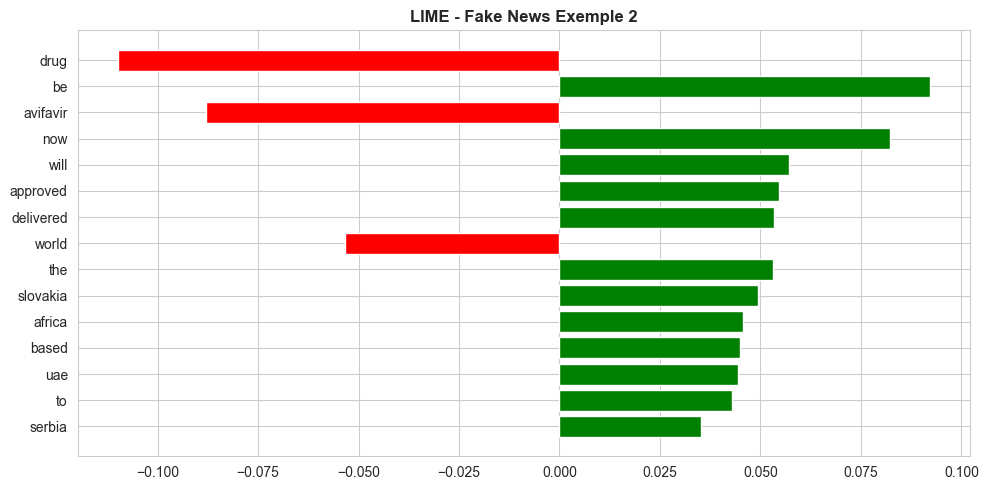

In [12]:
if LIME_AVAILABLE:
    print("=" * 60)
    print("LIME - EXPLICATIONS POUR FAKE NEWS")
    print("=" * 60)
    
    for i, (_, row) in enumerate(fake_samples.iterrows()):
        text = str(row['cleaned_text'])
        true_label = label_names[row['label_encoded']]
        
        print(f"\n--- Exemple Fake {i+1} ---")
        print(f"Texte : {text[:200]}")
        print(f"Vrai label : {true_label}")
        
        # Générer l'explication
        explanation = lime_explainer.explain_instance(
            text,
            predict_batch,
            num_features=15,
            num_samples=200
        )
        
        # Prédiction
        pred_result = predict_single(text)
        print(f"Prédiction : {pred_result['prediction']} ({pred_result['confidence']:.1%})")
        
        # Afficher les mots importants
        print(f"\nMots les plus importants :")
        for word, weight in explanation.as_list():
            direction = "-> FAKE" if weight < 0 else "-> REAL"
            print(f"  {word:20s} : {weight:+.4f} {direction}")
        
        # Visualisation
        fig = explanation.as_pyplot_figure()
        fig.set_size_inches(10, 5)
        plt.title(f'LIME - Fake News Exemple {i+1}', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'../reports/figures/lime_fake_{i+1}.png', dpi=150, bbox_inches='tight')
        plt.show()

LIME - EXPLICATIONS POUR REAL NEWS

--- Exemple Real 1 ---
Texte : rt niosh as a bank employer your workers could be exposed to the virus that causes covid19 while doing their job new information from
Vrai label : real


Prédiction : fake (76.7%)

Mots les plus importants :
  virus                : -0.2415 -> FAKE
  bank                 : -0.2140 -> FAKE
  workers              : +0.0889 -> REAL
  to                   : +0.0866 -> REAL
  niosh                : -0.0850 -> FAKE
  rt                   : +0.0842 -> REAL
  information          : +0.0812 -> REAL
  while                : +0.0643 -> REAL
  your                 : +0.0612 -> REAL
  as                   : +0.0492 -> REAL
  exposed              : -0.0454 -> FAKE
  employer             : +0.0440 -> REAL
  the                  : +0.0400 -> REAL
  covid19              : +0.0367 -> REAL
  causes               : -0.0279 -> FAKE


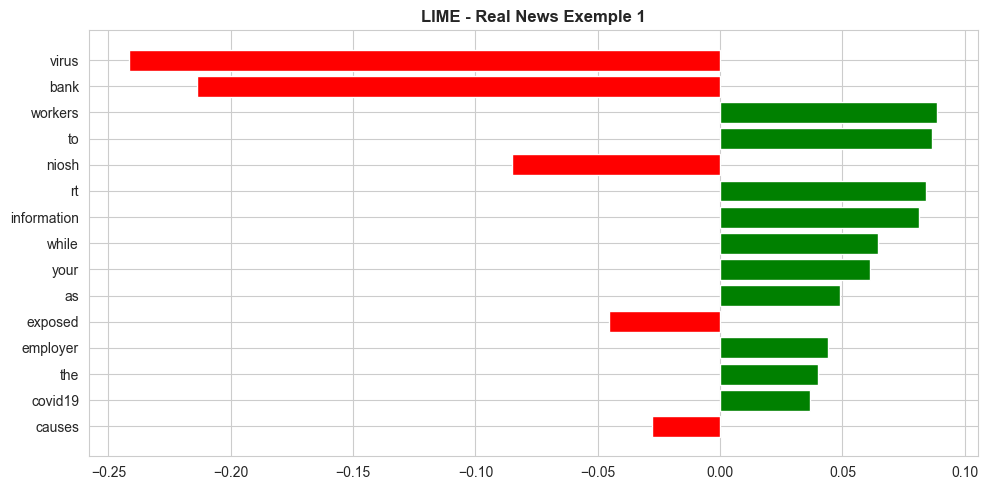


--- Exemple Real 2 ---
Texte : coronavirus slovenia and guadeloupe added to uk s quarantine list but thailand and singapore removed
Vrai label : real


Prédiction : fake (72.8%)

Mots les plus importants :
  uk                   : +0.1017 -> REAL
  coronavirus          : -0.0971 -> FAKE
  and                  : +0.0938 -> REAL
  removed              : -0.0407 -> FAKE
  added                : +0.0346 -> REAL
  singapore            : +0.0293 -> REAL
  to                   : +0.0217 -> REAL
  slovenia             : +0.0199 -> REAL
  s                    : +0.0180 -> REAL
  but                  : -0.0132 -> FAKE
  guadeloupe           : +0.0100 -> REAL
  list                 : -0.0097 -> FAKE
  quarantine           : +0.0053 -> REAL
  thailand             : -0.0034 -> FAKE


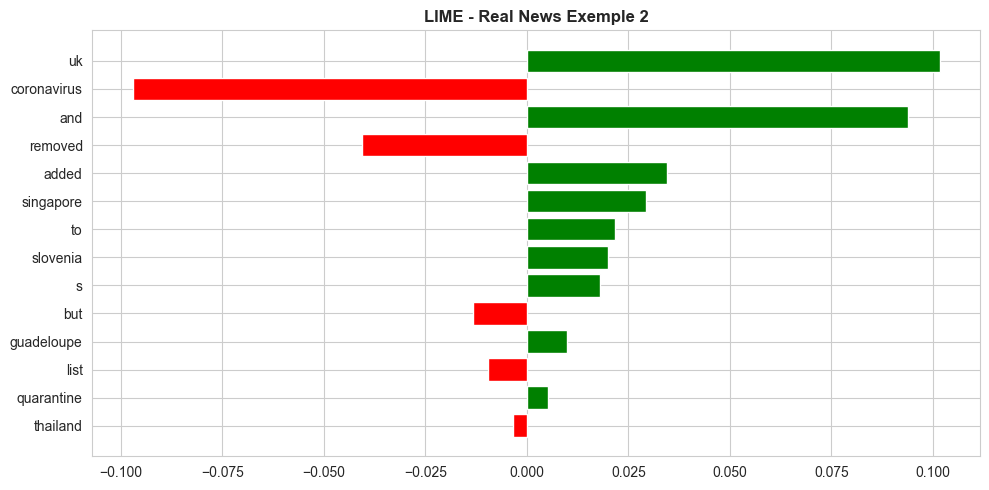

In [13]:
if LIME_AVAILABLE:
    print("=" * 60)
    print("LIME - EXPLICATIONS POUR REAL NEWS")
    print("=" * 60)
    
    for i, (_, row) in enumerate(real_samples.iterrows()):
        text = str(row['cleaned_text'])
        true_label = label_names[row['label_encoded']]
        
        print(f"\n--- Exemple Real {i+1} ---")
        print(f"Texte : {text[:200]}")
        print(f"Vrai label : {true_label}")
        
        explanation = lime_explainer.explain_instance(
            text,
            predict_batch,
            num_features=15,
            num_samples=200
        )
        
        pred_result = predict_single(text)
        print(f"Prédiction : {pred_result['prediction']} ({pred_result['confidence']:.1%})")
        
        print(f"\nMots les plus importants :")
        for word, weight in explanation.as_list():
            direction = "-> FAKE" if weight < 0 else "-> REAL"
            print(f"  {word:20s} : {weight:+.4f} {direction}")
        
        fig = explanation.as_pyplot_figure()
        fig.set_size_inches(10, 5)
        plt.title(f'LIME - Real News Exemple {i+1}', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'../reports/figures/lime_real_{i+1}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 6.5 Analyse SHAP

SHAP (SHapley Additive exPlanations) utilise la théorie des jeux pour attribuer une importance à chaque feature.

In [14]:
if SHAP_AVAILABLE:
    print("=" * 60)
    print("ANALYSE SHAP")
    print("=" * 60)
    
    # Créer un explainer SHAP pour le modèle BERT
    # On utilise shap.Explainer avec un pipeline de prédiction
    
    def shap_predict(texts):
        """Fonction de prédiction pour SHAP."""
        results = []
        for text in texts:
            pred = predict_single(text)
            # SHAP attend les probabilités de la classe positive
            results.append([pred['probabilities'][name] for name in label_names])
        return np.array(results)
    
    # Sélectionner un échantillon pour SHAP (plus lent que LIME)
    n_shap_samples = min(50, len(medium_texts))
    shap_texts = medium_texts['cleaned_text'].sample(n_shap_samples, random_state=42).tolist()
    
    print(f"Calcul des valeurs SHAP pour {n_shap_samples} textes...")
    print("(Cela peut prendre quelques minutes)")
    
    # Utiliser le masker pour le texte
    masker = shap.maskers.Text(tokenizer=r'\s+')
    
    explainer = shap.Explainer(
        shap_predict,
        masker,
        output_names=label_names
    )
    
    # Calculer les valeurs SHAP pour quelques exemples
    shap_sample_texts = shap_texts[:10]  # Limiter pour la rapidité
    shap_values = explainer(shap_sample_texts)
    
    print("Valeurs SHAP calculées.")
else:
    print("SHAP non disponible. Installer avec : pip install shap")

ANALYSE SHAP
Calcul des valeurs SHAP pour 50 textes...
(Cela peut prendre quelques minutes)


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:36<01:12, 10.39s/it]

...

PartitionExplainer explainer: 100%|██████████| 10/10 [01:59<00:00,  9.98s/it]

  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [02:12, 11.02s/it]                        

PartitionExplainer explainer: 11it [02:12, 13.26s/it]

Valeurs SHAP calculées.


In [15]:
if SHAP_AVAILABLE:
    # Visualisation SHAP : texte individuel
    print("Visualisation SHAP pour des exemples individuels :")
    
    for i in range(min(3, len(shap_sample_texts))):
        print(f"\n--- Exemple {i+1} ---")
        print(f"Texte : {shap_sample_texts[i][:150]}...")
        
        pred = predict_single(shap_sample_texts[i])
        print(f"Prédiction : {pred['prediction']} ({pred['confidence']:.1%})")
        
        # Afficher le plot SHAP
        shap.plots.text(shap_values[i], display=True)

Visualisation SHAP pour des exemples individuels :

--- Exemple 1 ---
Texte : what will remain of at home and telehealth innovations in the post covid era is the million dollar question...
Prédiction : fake (60.5%)



--- Exemple 2 ---
Texte : and it was under ihr that who declared a public health emergency of international concern on 30 january who s highest health security alert under inte...
Prédiction : fake (60.8%)



--- Exemple 3 ---
Texte : coronavirus head of test and trace says rise in demand for covid tests wasn t expected...
Prédiction : fake (84.0%)



Summary plot SHAP :


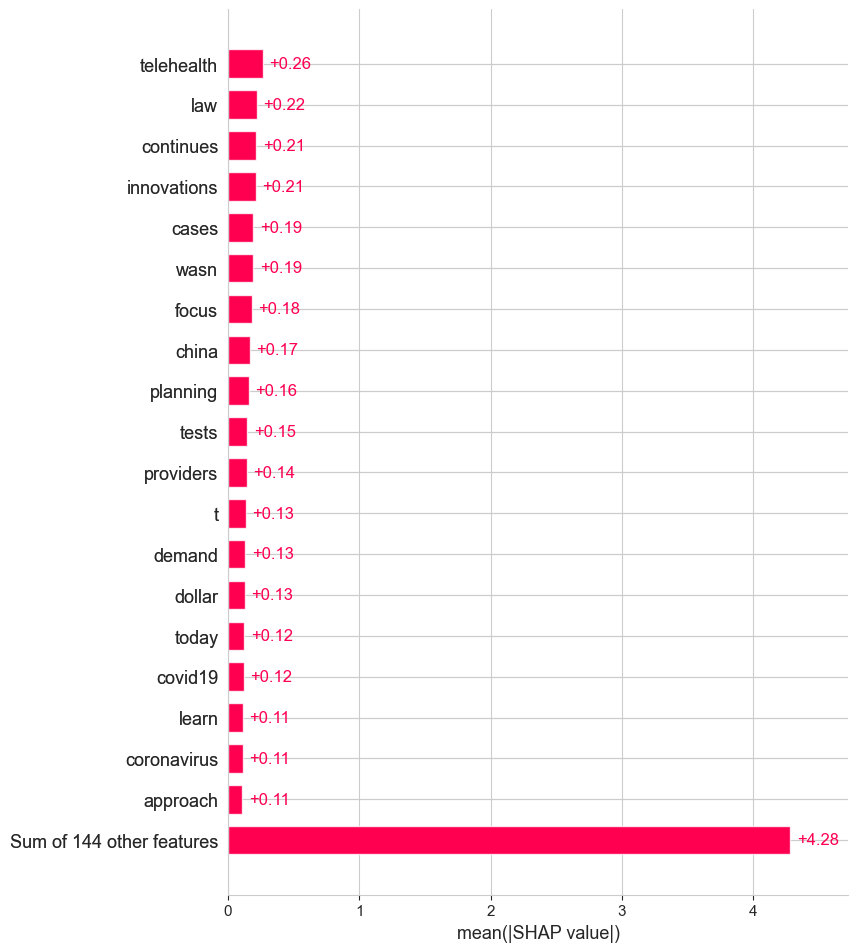

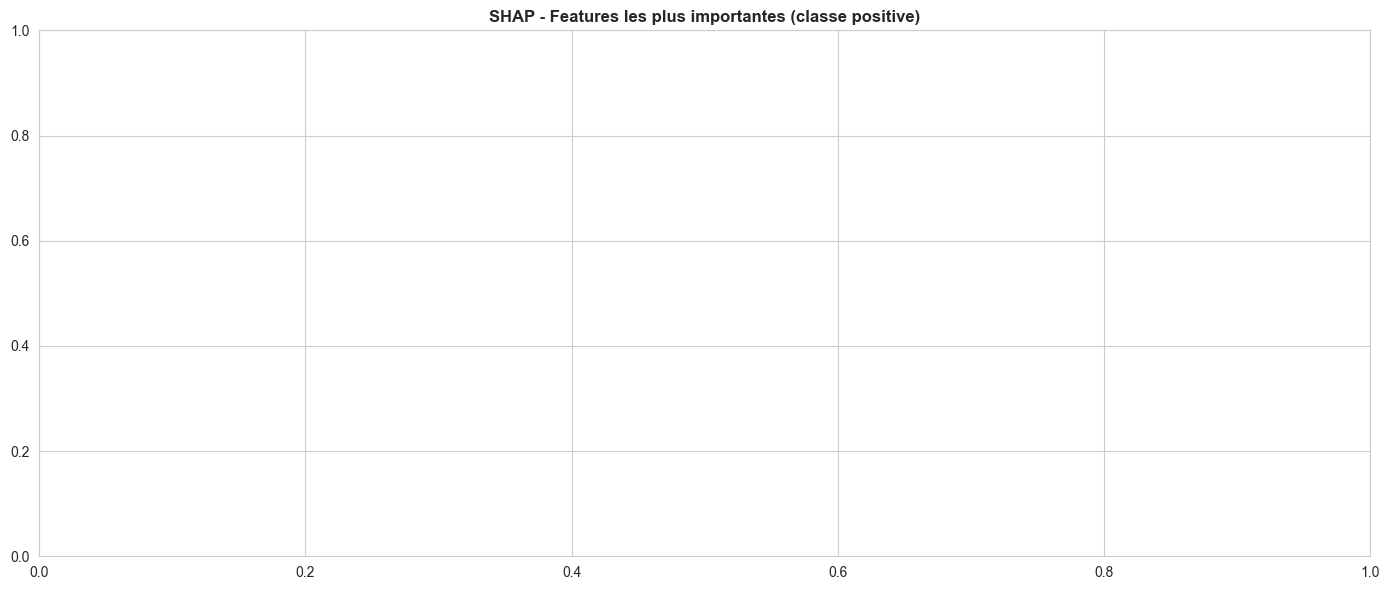

In [16]:
if SHAP_AVAILABLE:
    # Summary plot - importance globale des features
    print("\nSummary plot SHAP :")
    
    try:
        # Bar plot des features les plus importantes
        shap.plots.bar(shap_values[:, :, 1], max_display=20, show=True)
        plt.title('SHAP - Features les plus importantes (classe positive)', fontweight='bold')
        plt.tight_layout()
        plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Erreur lors de la création du summary plot : {e}")
        print("Le format des valeurs SHAP peut ne pas être compatible avec ce type de visualisation.")

## 6.6 Comparaison des méthodes d'explicabilité

Comparons les tokens identifiés comme importants par chaque méthode.

In [17]:
# Comparer les méthodes sur un même texte
comparison_text = str(medium_texts.iloc[0]['cleaned_text'])
print(f"Texte de comparaison : {comparison_text[:200]}...")
print()

# Attention
result_attn = predict_single(comparison_text, return_attention=True)
print(f"Prédiction : {result_attn['prediction']} ({result_attn['confidence']:.1%})")

methods_importance = {}

Texte de comparaison : chinese converting to islam after realising that no muslim was affected by coronavirus covd19 in the country...

Prédiction : fake (98.6%)


In [18]:
# 1. Attention - Top tokens
if 'attentions' in result_attn:
    attn = result_attn['attentions'][-1][0]  # Dernière couche
    n_real_tokens = int(result_attn['attention_mask'].sum())
    cls_attn = attn[:, 0, :n_real_tokens].mean(axis=0)  # Moyenne des têtes, attention depuis [CLS]
    tokens = result_attn['tokens'][:n_real_tokens]
    
    # Normaliser
    attn_importance = {t: float(s) for t, s in zip(tokens, cls_attn) if t not in ['[CLS]', '[SEP]', '[PAD]']}
    methods_importance['Attention'] = dict(sorted(attn_importance.items(), key=lambda x: -x[1])[:15])

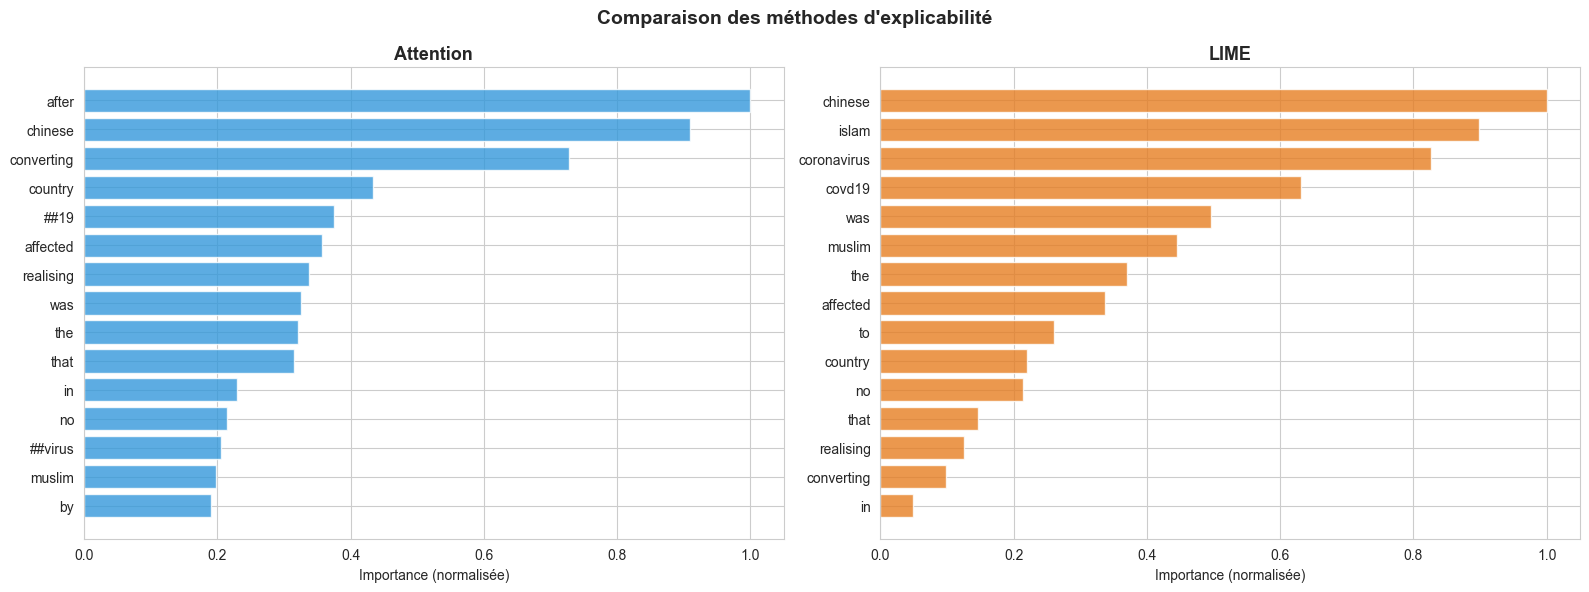

In [19]:
# 2. LIME
if LIME_AVAILABLE:
    lime_exp = lime_explainer.explain_instance(
        comparison_text, predict_batch, num_features=15, num_samples=200
    )
    methods_importance['LIME'] = {word: abs(weight) for word, weight in lime_exp.as_list()[:15]}

# Visualisation comparative
if methods_importance:
    n_methods = len(methods_importance)
    fig, axes = plt.subplots(1, n_methods, figsize=(8 * n_methods, 6))
    if n_methods == 1:
        axes = [axes]
    
    colors_map = {'Attention': '#3498db', 'LIME': '#e67e22', 'SHAP': '#9b59b6'}
    
    for idx, (method, importance) in enumerate(methods_importance.items()):
        words = list(importance.keys())
        scores = list(importance.values())
        
        # Normaliser les scores entre 0 et 1
        max_score = max(scores) if scores else 1
        scores_norm = [s / max_score for s in scores]
        
        axes[idx].barh(range(len(words)), scores_norm, color=colors_map.get(method, 'gray'), alpha=0.8)
        axes[idx].set_yticks(range(len(words)))
        axes[idx].set_yticklabels(words)
        axes[idx].invert_yaxis()
        axes[idx].set_title(f'{method}', fontweight='bold', fontsize=13)
        axes[idx].set_xlabel('Importance (normalisée)')
    
    plt.suptitle('Comparaison des méthodes d\'explicabilité', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/explainability_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6.7 Analyse des biais

Il est important d'analyser les biais potentiels du modèle pour éviter des décisions injustes.

In [20]:
# Tests de biais sur des mots spécifiques
print("=" * 60)
print("ANALYSE DES BIAIS")
print("=" * 60)

# Texte neutre de base
base_text = "the government announced new measures regarding public health"

ANALYSE DES BIAIS


In [21]:
# Variations avec différents termes potentiellement biaisés
bias_tests = {
    'Neutre': base_text,
    'Chine': base_text.replace('government', 'Chinese government'),
    'USA': base_text.replace('government', 'US government'),
    'OMS': base_text.replace('government', 'WHO'),
    'Vaccin': base_text.replace('public health', 'vaccination program'),
    'Conspiration': base_text.replace('measures', 'cover up') + ' the truth is hidden',
    'Source médicale': base_text.replace('government', 'medical researchers at Harvard'),
    'Réseaux sociaux': 'someone on facebook said that ' + base_text,
}

bias_results = []
for label, text in bias_tests.items():
    result = predict_single(text)
    bias_results.append({
        'Variante': label,
        'Texte': text[:80] + '...' if len(text) > 80 else text,
        'Prédiction': result['prediction'],
        'Confiance': result['confidence'],
        **result['probabilities']
    })

bias_df = pd.DataFrame(bias_results)
print(bias_df[['Variante', 'Prédiction', 'Confiance']].to_string(index=False))

       Variante Prédiction  Confiance
         Neutre       fake   0.532404
          Chine       fake   0.956400
            USA       fake   0.838874
            OMS       real   0.918868
         Vaccin       fake   0.930478
   Conspiration       fake   0.951100
Source médicale       fake   0.651853
Réseaux sociaux       fake   0.975313


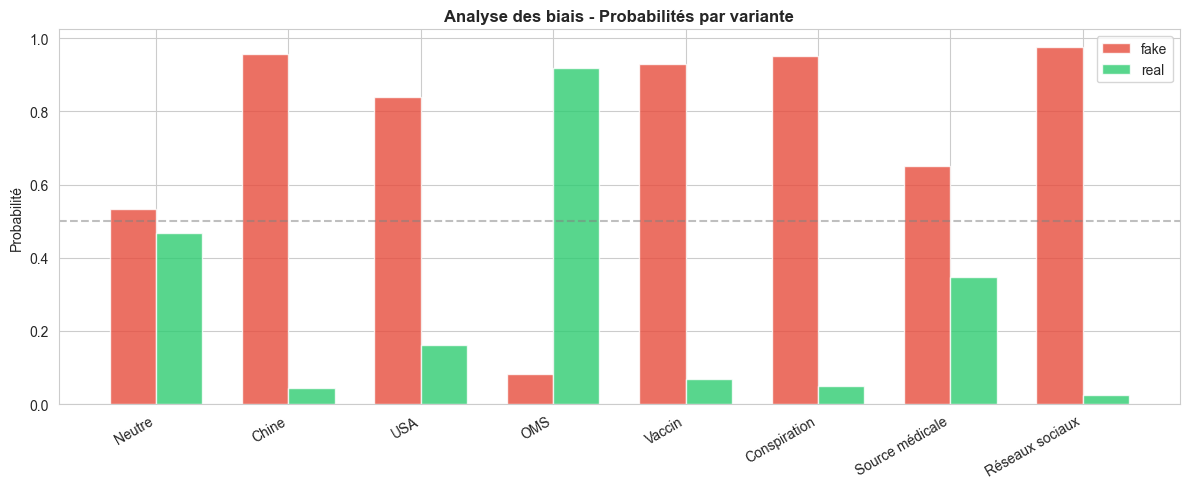

In [22]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(bias_df))
prob_cols = [c for c in bias_df.columns if c in label_names]

if len(prob_cols) >= 2:
    width = 0.35
    ax.bar([xi - width/2 for xi in x], bias_df[prob_cols[0]], width, label=prob_cols[0], color='#e74c3c', alpha=0.8)
    ax.bar([xi + width/2 for xi in x], bias_df[prob_cols[1]], width, label=prob_cols[1], color='#2ecc71', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(bias_df['Variante'], rotation=30, ha='right')
    ax.set_ylabel('Probabilité')
    ax.set_title('Analyse des biais - Probabilités par variante', fontweight='bold')
    ax.legend()
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../reports/figures/bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.8 Considérations éthiques

### Enjeux éthiques de la détection de fake news

#### 1. Risque de censure
Un système de détection automatique de fake news pourrait être utilisé pour censurer des opinions légitimes ou des points de vue dissidents. Il est crucial de :
- Utiliser le modèle comme un **outil d'aide à la décision**, pas comme un juge final
- Toujours permettre un recours humain
- Être transparent sur les limites du modèle

#### 2. Biais dans les données d'entraînement
Les données d'entraînement reflètent nécessairement les biais de ceux qui les ont annotées :
- **Biais politique** : Certains contenus peuvent être classés comme "fake" en raison de leur orientation politique plutôt que de leur fausseté factuelle
- **Biais culturel** : Le modèle est entraîné principalement sur du contenu anglophone occidental
- **Biais temporel** : Les informations classées comme "fake" peuvent devenir "real" avec le temps (ex: hypothèse de la fuite du laboratoire)

#### 3. Transparence et explicabilité
- Les utilisateurs doivent comprendre **pourquoi** un contenu est classé comme fake news
- Les méthodes d'explicabilité (LIME, SHAP, Attention) sont essentielles pour la confiance
- Le modèle doit fournir un **score de confiance** avec chaque prédiction

#### 4. Impact sur la liberté d'expression
- La détection automatique ne doit pas remplacer le fact-checking humain
- Les faux positifs (vrais articles classés comme fake) peuvent avoir un impact négatif sur les journalistes et créateurs de contenu
- Nécessité d'un seuil de décision ajustable selon le contexte

#### 5. Recommandations
- **Ne jamais déployer** ce modèle comme seul décideur pour supprimer du contenu
- **Combiner** avec d'autres méthodes de vérification (fact-checking, vérification des sources)
- **Auditer** régulièrement le modèle pour détecter des biais émergents
- **Documenter** clairement les limites et les cas d'utilisation prévus

## 6.9 Limitations et travaux futurs

### Limitations du modèle actuel

1. **Spécificité du domaine** : Le modèle est entraîné uniquement sur des données liées au COVID-19. Sa généralisation à d'autres sujets n'est pas garantie.

2. **Limitation linguistique** : Le modèle ne fonctionne qu'en anglais. Les fake news dans d'autres langues ne sont pas couvertes.

3. **Absence de contexte externe** : Le modèle n'utilise que le texte, sans prendre en compte :
   - La source de l'information
   - L'historique de l'auteur
   - Les métadonnées de partage (nombre de retweets, likes, etc.)
   - Les images ou vidéos associées

4. **Évolution de la désinformation** : Les stratégies de désinformation évoluent constamment, rendant le modèle potentiellement obsolète.

5. **Sensibilité aux attaques adversariales** : Des textes spécialement conçus pourraient tromper le modèle.

### Travaux futurs

1. **Modèle multilingue** : Utiliser mBERT ou XLM-RoBERTa pour couvrir plusieurs langues
2. **Modèle multimodal** : Combiner texte + images + métadonnées
3. **Apprentissage continuel** : Mettre à jour le modèle avec de nouvelles données sans oublier les anciennes
4. **Détection de la source** : Intégrer l'analyse de la crédibilité de la source
5. **Analyse du réseau de diffusion** : Étudier comment l'information se propage dans les réseaux sociaux
6. **Robustesse adversariale** : Entraîner le modèle avec des techniques d'augmentation adversariale

In [23]:
# Nettoyage
df_test = df_test.drop(columns=['_text_len'], errors='ignore')

if device.type == 'cuda':
    torch.cuda.empty_cache()

print("=" * 60)
print("ANALYSE D'EXPLICABILITÉ TERMINÉE")
print("=" * 60)
print("\nRésumé des méthodes utilisées :")
print("  1. Visualisation de l'attention BERT")
print("  2. LIME (explications locales)")
if SHAP_AVAILABLE:
    print("  3. SHAP (valeurs de Shapley)")
print("  4. Analyse des biais")
print("  5. Considérations éthiques")
print("\nTous les graphiques ont été sauvegardés dans ../reports/figures/")

ANALYSE D'EXPLICABILITÉ TERMINÉE

Résumé des méthodes utilisées :
  1. Visualisation de l'attention BERT
  2. LIME (explications locales)
  3. SHAP (valeurs de Shapley)
  4. Analyse des biais
  5. Considérations éthiques

Tous les graphiques ont été sauvegardés dans ../reports/figures/
